In [1]:
!pip install yfinance


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
data = yf.download(ticker, start="2022-01-01", end="2024-01-01")

data.head()

/tmp/ipython-input-463/2084720155.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000
2022-01-07,168.474869,170.402590,167.359336,169.179417,86709100


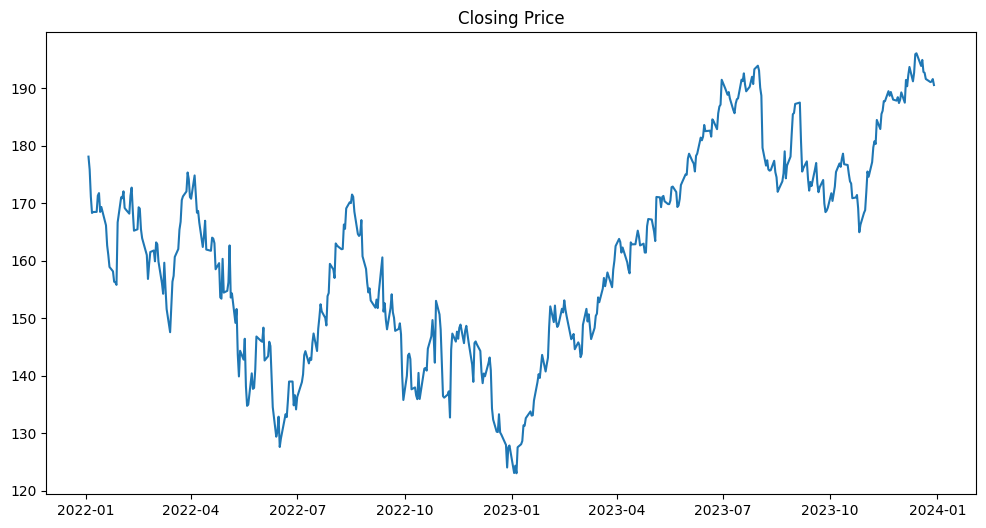

In [3]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("Closing Price")
plt.show()

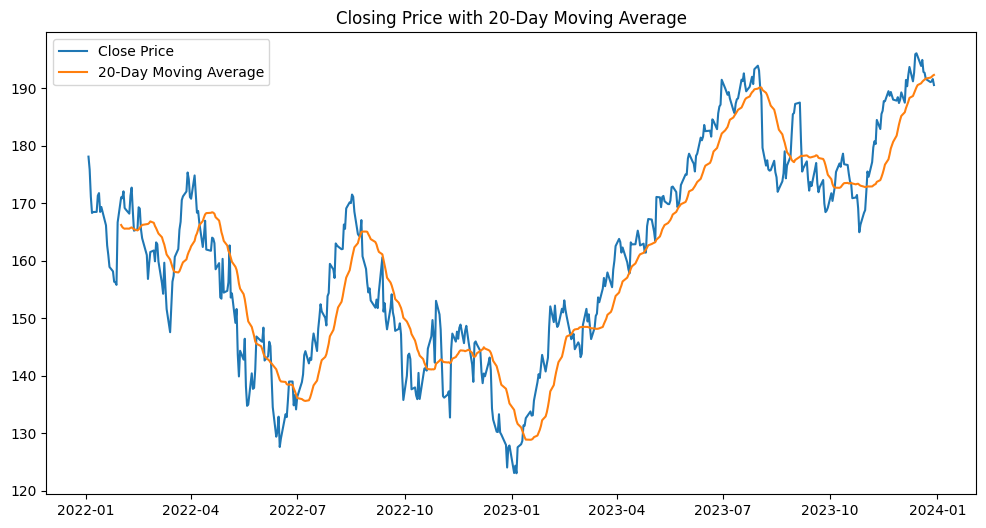

In [4]:
data['MA20'] = data['Close'].rolling(window=20).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Close Price")
plt.plot(data['MA20'], label="20-Day Moving Average")
plt.title("Closing Price with 20-Day Moving Average")
plt.legend()
plt.show()

In [5]:
data['Daily Return'] = data['Close'].pct_change()

data['Daily Return'].head()

,Daily Return
Date,
2022-01-03,NaN
2022-01-04,-0.012692
2022-01-05,-0.026600
2022-01-06,-0.016693
2022-01-07,0.000988


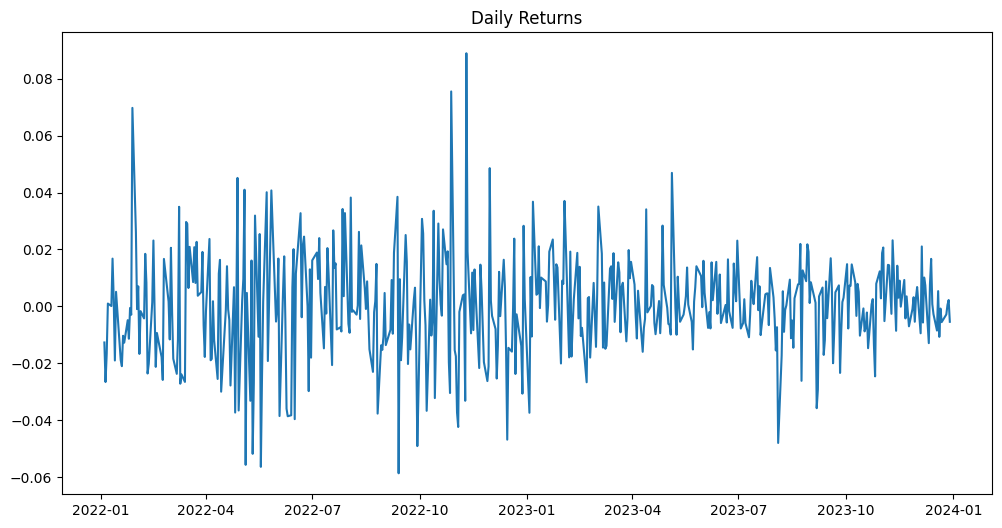

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'])
plt.title("Daily Returns")
plt.show()

In [7]:
volatility = data['Daily Return'].std()

print("Volatility (Risk):", volatility)

Volatility (Risk): 0.01831586840393521


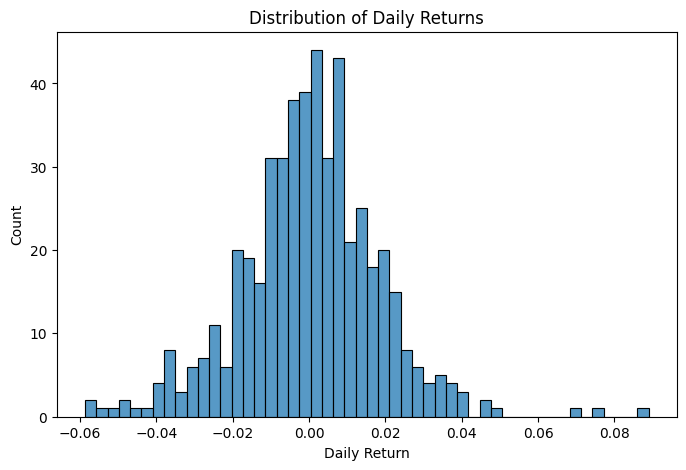

In [8]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['Daily Return'].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

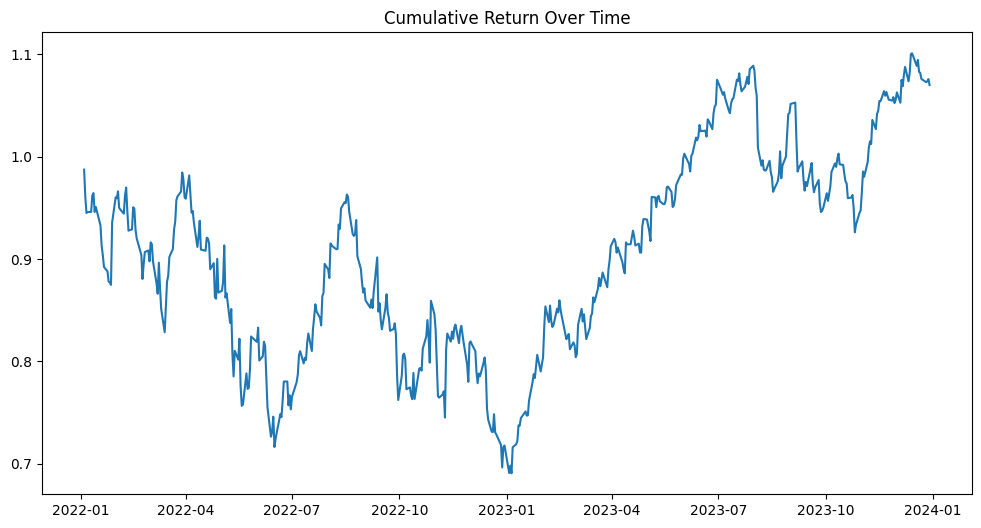

In [9]:
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(data['Cumulative Return'])
plt.title("Cumulative Return Over Time")
plt.show()

In [10]:
mean_return = data['Daily Return'].mean()
volatility = data['Daily Return'].std()

sharpe_ratio = mean_return / volatility

print("Average Daily Return:", mean_return)
print("Volatility (Risk):", volatility)
print("Sharpe Ratio:", sharpe_ratio)

Average Daily Return: 0.000302234240574637
Volatility (Risk): 0.01831586840393521
Sharpe Ratio: 0.016501223633475177


In [11]:
!pip install plotly

In [13]:
fig = px.line(
    x=data.index,
    y=data['Close'].values.flatten(),
    title="Interactive Closing Price Chart"
)

fig.show()

In [14]:
data['MA20'] = data['Close'].rolling(20).mean()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data.index,
    y=data['Close'].values.flatten(),
    mode='lines',
    name='Close Price'
))

fig.add_trace(go.Scatter(
    x=data.index,
    y=data['MA20'].values.flatten(),
    mode='lines',
    name='20-Day Moving Average'
))

fig.update_layout(
    title="Stock Price with 20-Day Moving Average",
    template="plotly_dark"
)

fig.show()

In [15]:
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

fig = px.line(
    x=data.index,
    y=data['Cumulative Return'].values.flatten(),
    title="Cumulative Return Over Time",
    template="plotly_dark"
)

fig.show()

In [16]:
mean_return = data['Daily Return'].mean()
volatility = data['Daily Return'].std()

print("Average Daily Return:", mean_return)
print("Volatility (Risk):", volatility)
print("Sharpe Ratio:", mean_return / volatility)

Average Daily Return: 0.000302234240574637
Volatility (Risk): 0.01831586840393521
Sharpe Ratio: 0.016501223633475177


In [17]:
stocks = ["AAPL", "MSFT", "TSLA"]

multi_data = yf.download(stocks, start="2022-01-01", end="2024-01-01")["Close"]

fig = px.line(
    multi_data,
    x=multi_data.index,
    y=multi_data.columns,
    title="Stock Price Comparison",
    template="plotly_dark"
)

fig.show()

/tmp/ipython-input-463/4205715017.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


In [18]:
stocks = ["AAPL", "MSFT", "TSLA"]

data = yf.download(stocks, start="2022-01-01", end="2024-01-01")["Close"]

returns = data.pct_change().dropna()

/tmp/ipython-input-463/3293232317.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


In [19]:
cumulative_returns = (1 + returns).cumprod()

import plotly.express as px

fig = px.line(
    cumulative_returns,
    x=cumulative_returns.index,
    y=cumulative_returns.columns,
    title="Cumulative Return Comparison",
    template="plotly_dark"
)

fig.show()

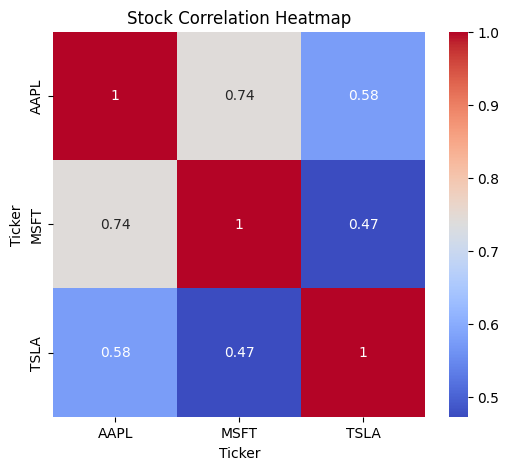

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Stock Correlation Heatmap")
plt.show()

In [21]:
import numpy as np

mean_returns = returns.mean()
volatility = returns.std()

analysis = pd.DataFrame({
    "Return": mean_returns,
    "Risk": volatility
})

fig = px.scatter(
    analysis,
    x="Risk",
    y="Return",
    text=analysis.index,
    title="Risk vs Return Analysis",
    template="plotly_dark"
)

fig.update_traces(textposition='top center')
fig.show()

In [22]:
analysis["Sharpe Ratio"] = analysis["Return"] / analysis["Risk"]

analysis

,Return,Risk,Sharpe Ratio
Ticker,,,
AAPL,0.000302,0.018316,0.016501
MSFT,0.000456,0.019355,0.023540
TSLA,-0.000230,0.037905,-0.006068


In [26]:
weights = np.array([0.4, 0.3, 0.3])
stocks = ["AAPL", "MSFT", "TSLA"]

In [27]:
portfolio_return = np.sum(returns.mean() * weights)

portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(returns.cov(), weights))
)

print("Portfolio Expected Return:", portfolio_return)
print("Portfolio Volatility (Risk):", portfolio_volatility)
print("Portfolio Sharpe Ratio:", portfolio_return / portfolio_volatility)

Portfolio Expected Return: 0.0001885782700474119
Portfolio Volatility (Risk): 0.02094006957177505
Portfolio Sharpe Ratio: 0.009005618123714117


In [28]:
portfolio_daily_return = returns.dot(weights)

portfolio_cumulative = (1 + portfolio_daily_return).cumprod()

fig = px.line(
    portfolio_cumulative,
    title="Portfolio Cumulative Return",
    template="plotly_dark"
)

fig.show()

In [29]:
comparison = cumulative_returns.copy()
comparison["Portfolio"] = portfolio_cumulative

fig = px.line(
    comparison,
    title="Stocks vs Portfolio Performance",
    template="plotly_dark"
)

fig.show()

In [30]:
ticker = "AAPL"

data_single = yf.download(ticker, start="2022-01-01", end="2024-01-01")["Close"]

returns_single = data_single.pct_change().dropna()

mean_return = returns_single.mean()
volatility = returns_single.std()

/tmp/ipython-input-463/2720463495.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [31]:
num_simulations = 100
num_days = 252  # 1 year trading days

last_price = data_single.iloc[-1]

In [32]:
simulation_df = pd.DataFrame()

for i in range(num_simulations):
    prices = [last_price]

    for d in range(num_days):
        next_price = prices[-1] * (1 + np.random.normal(mean_return, volatility))
        prices.append(next_price)

    simulation_df[i] = prices

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



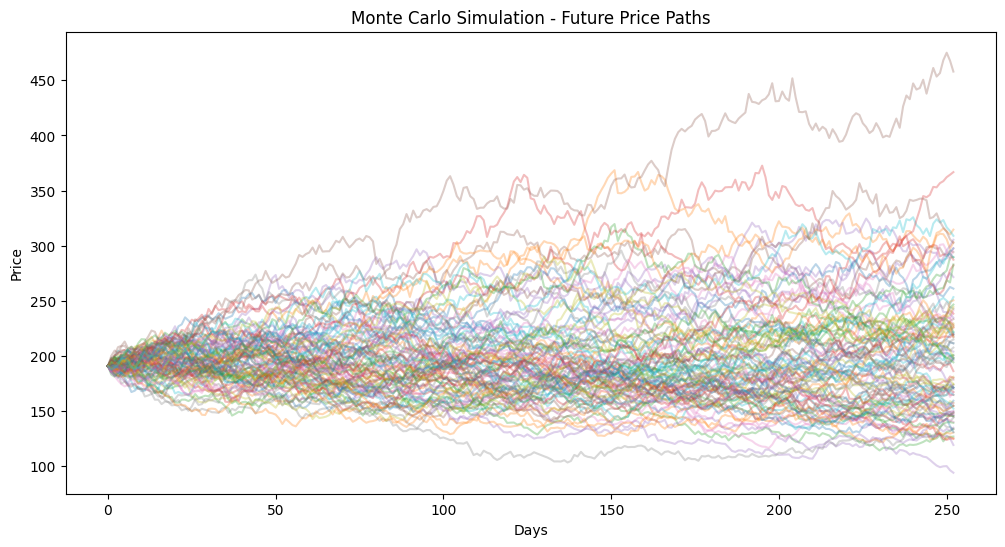

In [33]:
plt.figure(figsize=(12,6))

for i in simulation_df.columns:
    plt.plot(simulation_df[i], alpha=0.3)

plt.title("Monte Carlo Simulation - Future Price Paths")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [41]:
simulation_results = []

for i in range(num_simulations):
    prices = [float(last_price)]

    for d in range(num_days):
        next_price = prices[-1] * (1 + np.random.normal(mean_return, volatility))
        prices.append(float(next_price))

    simulation_results.append(prices)

simulation_array = np.array(simulation_results)

/tmp/ipython-input-463/1042667547.py:4: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/tmp/ipython-input-463/1042667547.py:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



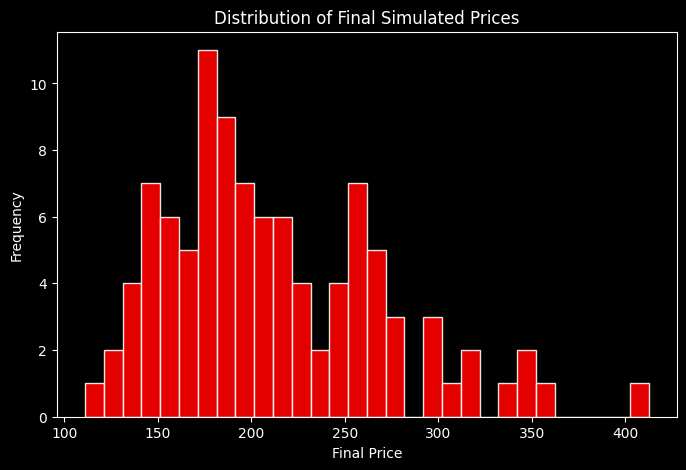

In [45]:
plt.style.use("dark_background")

final_prices = simulation_array[:, -1]

plt.figure(figsize=(8,5))
plt.hist(final_prices, bins=30, color="red", edgecolor="white", alpha=0.9)
plt.title("Distribution of Final Simulated Prices")
plt.xlabel("Final Price")
plt.ylabel("Frequency")
plt.show()

Monte Carlo simulation was used to estimate possible future stock prices
based on historical return and volatility.

The distribution shows the expected price range over one year.
The 5th percentile represents downside risk,
while the 95th percentile represents strong upside potential.

This helps investors understand risk exposure and make informed decisions.